In [1]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print(
    "GPU devices:",
    tf.config.list_physical_devices("GPU"),
)

if not tf.config.list_physical_devices("GPU"):
    raise RuntimeError(
        "GPU не найден. Включите Accelerator -> GPU."
    )

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from pathlib import Path
import shutil


SOURCE_ROOT = Path(
    "/kaggle/input/datasets/yuriyrizoboyev/"
    "traffic-sign-project-code/Traffic_Sign_Kaggle"
)

PROJECT_ROOT = Path(
    "/kaggle/working/traffic_sign_project"
)

DATASET_ROOT = Path(
    "/kaggle/input/datasets/meowmeowmeowmeowmeow/"
    "gtsrb-german-traffic-sign"
)


if not SOURCE_ROOT.exists():
    raise FileNotFoundError(
        f"Не найдена папка с кодом:\n{SOURCE_ROOT}"
    )

if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f"Не найден GTSRB:\n{DATASET_ROOT}"
    )


# Удаляем старую рабочую копию,
# если ячейка выполняется повторно.
if PROJECT_ROOT.exists():
    shutil.rmtree(PROJECT_ROOT)


shutil.copytree(
    SOURCE_ROOT,
    PROJECT_ROOT,
)


PREPARED_ROOT = (
    PROJECT_ROOT
    / "prepared_data"
)


print("PROJECT_ROOT:", PROJECT_ROOT)
print("PREPARED_ROOT:", PREPARED_ROOT)
print("DATASET_ROOT:", DATASET_ROOT)

PROJECT_ROOT: /kaggle/working/traffic_sign_project
PREPARED_ROOT: /kaggle/working/traffic_sign_project/prepared_data
DATASET_ROOT: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign


In [3]:
required_paths = [
    PROJECT_ROOT / "data_pipeline.py",

    PREPARED_ROOT / "train_manifest.csv",
    PREPARED_ROOT / "validation_manifest.csv",

    DATASET_ROOT / "Train.csv",
    DATASET_ROOT / "Test.csv",

    DATASET_ROOT / "Train",
    DATASET_ROOT / "Test",
]


missing_paths = []


for path in required_paths:
    if path.exists():
        print("OK:", path)
    else:
        print("MISSING:", path)
        missing_paths.append(path)


if missing_paths:
    raise FileNotFoundError(
        f"Не найдены обязательные файлы:\n"
        f"{missing_paths}"
    )


print("\nВсе необходимые файлы найдены.")

OK: /kaggle/working/traffic_sign_project/data_pipeline.py
OK: /kaggle/working/traffic_sign_project/prepared_data/train_manifest.csv
OK: /kaggle/working/traffic_sign_project/prepared_data/validation_manifest.csv
OK: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train.csv
OK: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv
OK: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train
OK: /kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test

Все необходимые файлы найдены.


In [4]:
config_text = f'''
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Literal


NormalizationMode = Literal[
    "zero_one",
    "minus_one_one",
    "none",
]


@dataclass(frozen=True)
class DataConfig:
    image_height: int = 224
    image_width: int = 224
    augmentation_resize: int = 240
    channels: int = 3
    number_of_classes: int = 43

    batch_size: int = 32
    shuffle_buffer: int = 10000
    random_seed: int = 42

    # EfficientNetV2 получает изображения 0..255.
    normalization_mode: NormalizationMode = "none"

    rotation_factor: float = 0.03
    translation_factor: float = 0.05
    zoom_factor: float = 0.08
    brightness_factor: float = 0.12
    contrast_factor: float = 0.12

    noise_probability: float = 0.15
    noise_stddev_255: float = 4.0
    blur_probability: float = 0.15

    deterministic_pipeline: bool = True

    @property
    def dataset_root(self) -> Path:
        return Path(
            r"{DATASET_ROOT}"
        )

    @property
    def prepared_data_root(self) -> Path:
        return Path(
            r"{PREPARED_ROOT}"
        )

    @property
    def train_manifest_path(self) -> Path:
        return (
            self.prepared_data_root
            / "train_manifest.csv"
        )

    @property
    def validation_manifest_path(self) -> Path:
        return (
            self.prepared_data_root
            / "validation_manifest.csv"
        )

    @property
    def test_manifest_path(self) -> Path:
        return (
            self.dataset_root
            / "Test.csv"
        )

    @property
    def output_root(self) -> Path:
        return Path(
            "/kaggle/working/"
            "efficientnetv2_outputs"
        )

    @property
    def figure_root(self) -> Path:
        return (
            self.output_root
            / "figures"
        )

    @property
    def report_root(self) -> Path:
        return (
            self.output_root
            / "reports"
        )

    def to_serializable_dict(self) -> dict[str, object]:
        return {{
            "dataset_root": str(
                self.dataset_root
            ),
            "prepared_data_root": str(
                self.prepared_data_root
            ),
            "image_height": self.image_height,
            "image_width": self.image_width,
            "channels": self.channels,
            "number_of_classes": (
                self.number_of_classes
            ),
            "batch_size": self.batch_size,
            "random_seed": self.random_seed,
            "normalization_mode": (
                self.normalization_mode
            ),
        }}
'''


config_path = (
    PROJECT_ROOT
    / "config.py"
)


config_path.write_text(
    config_text,
    encoding="utf-8",
)


print("EfficientNetV2 config created:")
print(config_path)

EfficientNetV2 config created:
/kaggle/working/traffic_sign_project/config.py


In [5]:
import sys
import importlib


project_path = str(PROJECT_ROOT)


if project_path not in sys.path:
    sys.path.insert(
        0,
        project_path,
    )


for module_name in [
    "config",
    "data_pipeline",
]:
    sys.modules.pop(
        module_name,
        None,
    )


importlib.invalidate_caches()


from config import DataConfig

from data_pipeline import (
    build_all_datasets,
    set_global_seed,
)


print("Data pipeline imported successfully.")

Data pipeline imported successfully.


In [6]:
set_global_seed(42)


config = DataConfig(
    batch_size=32,
)


data = build_all_datasets(
    config
)


train_ds = data[
    "train_dataset"
]

validation_ds = data[
    "validation_dataset"
]

test_ds = data[
    "test_dataset"
]

class_weights = data[
    "class_weights"
]


print(
    "Training images:",
    len(data["train_frame"]),
)

print(
    "Validation images:",
    len(data["validation_frame"]),
)

print(
    "Test images:",
    len(data["test_frame"]),
)

I0000 00:00:1784686455.169193      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Training images: 31372
Validation images: 7829
Test images: 12630


In [7]:
images, labels = next(
    iter(train_ds)
)


pixel_minimum = float(
    tf.reduce_min(images).numpy()
)

pixel_maximum = float(
    tf.reduce_max(images).numpy()
)


print(
    "Images shape:",
    images.shape,
)

print(
    "Labels shape:",
    labels.shape,
)

print(
    "Pixel minimum:",
    pixel_minimum,
)

print(
    "Pixel maximum:",
    pixel_maximum,
)


if pixel_minimum < 0:
    raise ValueError(
        "Найдены отрицательные значения пикселей."
    )

if pixel_maximum > 255.01:
    raise ValueError(
        "Значения пикселей превышают 255."
    )

Images shape: (32, 224, 224, 3)
Labels shape: (32,)
Pixel minimum: 0.0
Pixel maximum: 255.0


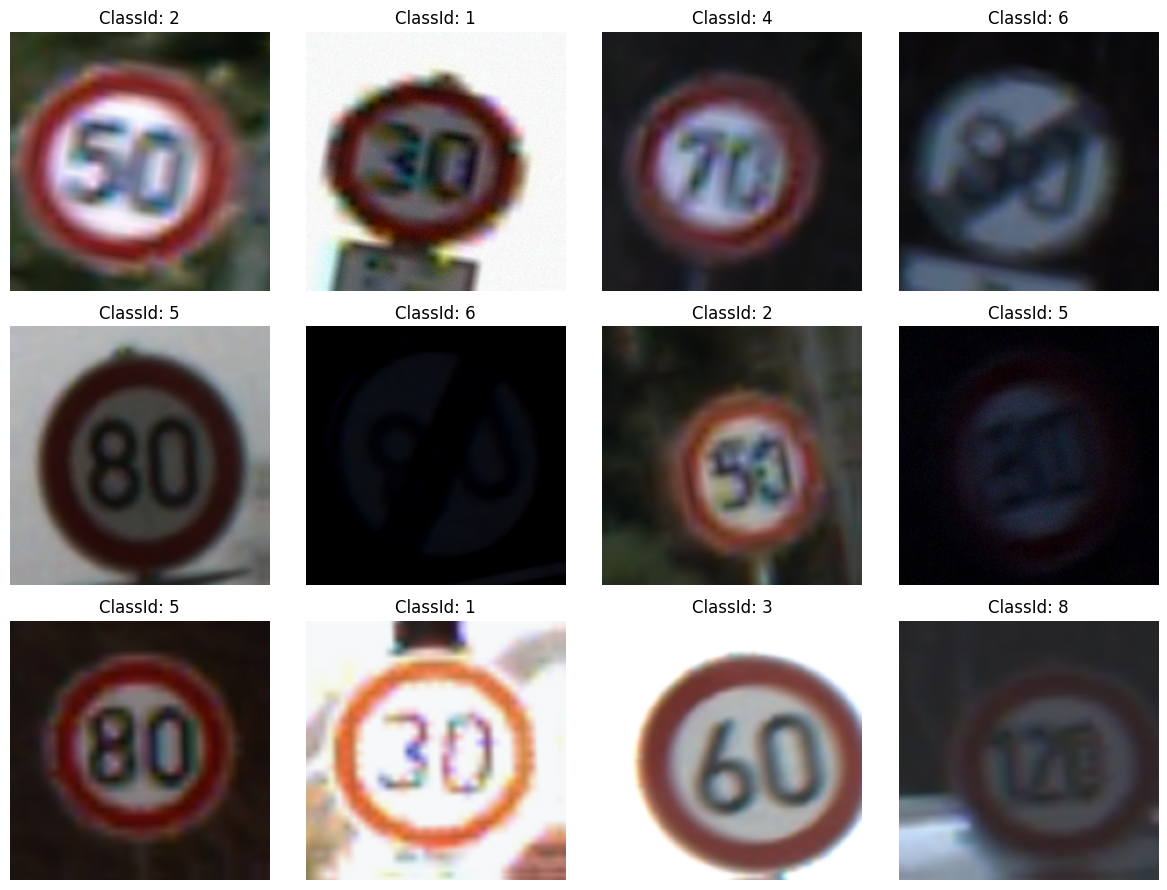

In [8]:
import matplotlib.pyplot as plt
import numpy as np


figure, axes = plt.subplots(
    3,
    4,
    figsize=(12, 9),
)


for index, axis in enumerate(
    axes.ravel()
):
    image = images[
        index
    ].numpy()

    image = np.clip(
        image,
        0,
        255,
    ).astype(np.uint8)

    axis.imshow(image)

    axis.set_title(
        f"ClassId: "
        f"{int(labels[index])}"
    )

    axis.axis("off")


plt.tight_layout()
plt.show()

In [9]:
def build_efficientnetv2_model(
    input_shape=(224, 224, 3),
    number_of_classes=43,
):
    base_model = (
        tf.keras.applications
        .EfficientNetV2B0(
            include_top=False,
            weights="imagenet",
            input_shape=input_shape,

            # Модель сама выполняет preprocessing.
            include_preprocessing=True,
        )
    )

    # Этап 1:
    # EfficientNetV2 пока не обучается.
    base_model.trainable = False


    inputs = tf.keras.Input(
        shape=input_shape,
        name="image",
    )


    # training=False особенно важно
    # для BatchNormalization.
    x = base_model(
        inputs,
        training=False,
    )


    x = (
        tf.keras.layers
        .GlobalAveragePooling2D(
            name="global_average_pool",
        )(x)
    )


    x = (
        tf.keras.layers
        .BatchNormalization(
            name="classifier_batch_norm",
        )(x)
    )


    x = tf.keras.layers.Dropout(
        0.30,
        name="classifier_dropout_1",
    )(x)


    x = tf.keras.layers.Dense(
        256,
        activation="relu",
        name="classifier_dense",
    )(x)


    x = tf.keras.layers.Dropout(
        0.30,
        name="classifier_dropout_2",
    )(x)


    outputs = tf.keras.layers.Dense(
        number_of_classes,
        activation="softmax",
        dtype="float32",
        name="class_probabilities",
    )(x)


    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="efficientnetv2b0_gtsrb",
    )


    return model, base_model

def compile_efficientnetv2(
    model,
    learning_rate,
):
    model.compile(
        optimizer=(
            tf.keras.optimizers.Adam(
                learning_rate=learning_rate,
            )
        ),

        loss=(
            tf.keras.losses
            .SparseCategoricalCrossentropy()
        ),

        metrics=[
            (
                tf.keras.metrics
                .SparseCategoricalAccuracy(
                    name="sparse_accuracy",
                )
            ),

            (
                tf.keras.metrics
                .SparseTopKCategoricalAccuracy(
                    k=3,
                    name="top3_accuracy",
                )
            ),
        ],
    )

In [10]:
tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(
    42
)


smoke_model, smoke_base_model = (
    build_efficientnetv2_model()
)


compile_efficientnetv2(
    smoke_model,
    learning_rate=0.001,
)


smoke_history = smoke_model.fit(
    train_ds,

    validation_data=validation_ds,

    epochs=1,

    steps_per_epoch=5,

    validation_steps=2,

    class_weight=class_weights,

    verbose=1,
)


print(
    "EfficientNetV2 smoke test completed."
)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 2.4936 - sparse_accuracy: 0.0717 - top3_accuracy: 0.1836

I0000 00:00:1784686491.300091      66 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - loss: 2.6337 - sparse_accuracy: 0.0875 - top3_accuracy: 0.2125 - val_loss: 3.4499 - val_sparse_accuracy: 0.1094 - val_top3_accuracy: 0.4375
EfficientNetV2 smoke test completed.


In [11]:
from pathlib import Path


OUTPUT_ROOT = Path(
    "/kaggle/working/"
    "efficientnetv2_outputs"
)


MODEL_DIR = (
    OUTPUT_ROOT
    / "models"
)

REPORT_DIR = (
    OUTPUT_ROOT
    / "reports"
)

FIGURE_DIR = (
    OUTPUT_ROOT
    / "figures"
)

LOG_DIR = (
    OUTPUT_ROOT
    / "logs"
)


for directory in [
    MODEL_DIR,
    REPORT_DIR,
    FIGURE_DIR,
    LOG_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


print(
    "Results will be saved to:",
    OUTPUT_ROOT,
)

Results will be saved to: /kaggle/working/efficientnetv2_outputs


In [12]:
tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(
    42
)


model, base_model = (
    build_efficientnetv2_model()
)


compile_efficientnetv2(
    model,
    learning_rate=0.001,
)


print(
    "Total parameters:",
    model.count_params(),
)


trainable_parameter_count = sum(
    tf.keras.backend.count_params(
        weight
    )
    for weight in model.trainable_weights
)


print(
    "Trainable parameters at stage 1:",
    trainable_parameter_count,
)

Total parameters: 6263419
Trainable parameters at stage 1: 341547


In [13]:
model_summary_lines = []


model.summary(
    print_fn=model_summary_lines.append
)


(
    REPORT_DIR
    / "model_summary.txt"
).write_text(
    "\n".join(
        model_summary_lines
    ),
    encoding="utf-8",
)


print(
    "\n".join(
        model_summary_lines
    )
)

Model: "efficientnetv2b0_gtsrb"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pool             │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier_batch_norm           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼─────────

In [14]:
stage1_weights_path = (
    MODEL_DIR
    / "best_frozen_head.weights.h5"
)


stage1_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            stage1_weights_path
        ),

        monitor="val_loss",

        mode="min",

        save_best_only=True,

        save_weights_only=True,

        verbose=1,
    ),


    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",

        mode="min",

        patience=3,

        restore_best_weights=True,

        verbose=1,
    ),


    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",

        mode="min",

        factor=0.5,

        patience=2,

        min_lr=1e-6,

        verbose=1,
    ),


    tf.keras.callbacks.CSVLogger(
        filename=str(
            LOG_DIR
            / "stage1_training_log.csv"
        ),

        append=False,
    ),


    tf.keras.callbacks.TerminateOnNaN(),
]

In [15]:
import time


stage1_start = (
    time.perf_counter()
)


history_stage1 = model.fit(
    train_ds,

    validation_data=validation_ds,

    epochs=10,

    class_weight=class_weights,

    callbacks=stage1_callbacks,

    verbose=1,
)


stage1_seconds = (
    time.perf_counter()
    - stage1_start
)


print(
    "Stage 1 training time, minutes:",
    stage1_seconds / 60,
)

Epoch 1/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - loss: 1.2021 - sparse_accuracy: 0.5530 - top3_accuracy: 0.7976
Epoch 1: val_loss improved from None to 0.96692, saving model to /kaggle/working/efficientnetv2_outputs/models/best_frozen_head.weights.h5

Epoch 1: finished saving model to /kaggle/working/efficientnetv2_outputs/models/best_frozen_head.weights.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 303s 285ms/step - loss: 1.3936 - sparse_accuracy: 0.6141 - top3_accuracy: 0.8400 - val_loss: 0.9669 - val_sparse_accuracy: 0.6843 - val_top3_accuracy: 0.9032 - learning_rate: 0.0010
Epoch 2/10
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - loss: 0.6965 - sparse_accuracy: 0.6678 - top3_accuracy: 0.8723
Epoch 2: val_loss improved from 0.96692 to 0.81848, saving model to /kaggle/working/efficientnetv2_outputs/models/best_frozen_head.weights.h5

Epoch 2: finished saving model to /kaggle/working/efficientnetv2_outputs/models/best_frozen_head.weights.h5
981/981 ━━━━━━━━━━━━━━━━━━━━ 231s 236ms/step - loss:

In [16]:
model.load_weights(
    stage1_weights_path
)

print(
    "Best stage 1 weights loaded."
)

Best stage 1 weights loaded.


In [17]:
base_model.trainable = True


number_of_layers = len(
    base_model.layers
)


fine_tune_from = max(
    0,
    number_of_layers - 40,
)


# Старые слои остаются замороженными.
for layer in base_model.layers[
    :fine_tune_from
]:
    layer.trainable = False


# Последние 40 слоёв можно обучать,
# но BatchNormalization оставляем
# замороженной.
for layer in base_model.layers[
    fine_tune_from:
]:
    if isinstance(
        layer,
        tf.keras.layers.BatchNormalization,
    ):
        layer.trainable = False
    else:
        layer.trainable = True


# После изменения trainable
# модель обязательно нужно
# скомпилировать заново.
compile_efficientnetv2(
    model,
    learning_rate=0.00001,
)


print(
    "Total backbone layers:",
    number_of_layers,
)

print(
    "Fine-tuning starts from layer:",
    fine_tune_from,
)


fine_tuning_parameters = sum(
    tf.keras.backend.count_params(
        weight
    )
    for weight in model.trainable_weights
)


print(
    "Trainable parameters at stage 2:",
    fine_tuning_parameters,
)

Total backbone layers: 270
Fine-tuning starts from layer: 230
Trainable parameters at stage 2: 2049339


In [18]:
best_model_path = (
    MODEL_DIR
    / "best_efficientnetv2b0.keras"
)


stage2_callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            best_model_path
        ),

        monitor="val_loss",

        mode="min",

        save_best_only=True,

        verbose=1,
    ),


    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",

        mode="min",

        patience=4,

        restore_best_weights=True,

        verbose=1,
    ),


    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",

        mode="min",

        factor=0.5,

        patience=2,

        min_lr=1e-7,

        verbose=1,
    ),


    tf.keras.callbacks.CSVLogger(
        filename=str(
            LOG_DIR
            / "stage2_finetuning_log.csv"
        ),

        append=False,
    ),


    tf.keras.callbacks.TerminateOnNaN(),
]

In [19]:
completed_stage1_epochs = len(
    history_stage1.history["loss"]
)


additional_fine_tuning_epochs = 15


stage2_start = (
    time.perf_counter()
)


history_stage2 = model.fit(
    train_ds,

    validation_data=validation_ds,

    initial_epoch=(
        completed_stage1_epochs
    ),

    epochs=(
        completed_stage1_epochs
        + additional_fine_tuning_epochs
    ),

    class_weight=class_weights,

    callbacks=stage2_callbacks,

    verbose=1,
)


stage2_seconds = (
    time.perf_counter()
    - stage2_start
)


print(
    "Stage 2 training time, minutes:",
    stage2_seconds / 60,
)

Epoch 11/25


2026-07-22 02:54:59.677223: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 02:54:59.883293: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


980/981 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - loss: 0.6010 - sparse_accuracy: 0.6763 - top3_accuracy: 0.8847

2026-07-22 02:59:02.687423: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-22 02:59:02.891924: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - loss: 0.6009 - sparse_accuracy: 0.6764 - top3_accuracy: 0.8847
Epoch 11: val_loss improved from None to 0.56909, saving model to /kaggle/working/efficientnetv2_outputs/models/best_efficientnetv2b0.keras

Epoch 11: finished saving model to /kaggle/working/efficientnetv2_outputs/models/best_efficientnetv2b0.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 290s 266ms/step - loss: 0.4933 - sparse_accuracy: 0.7795 - top3_accuracy: 0.9358 - val_loss: 0.5691 - val_sparse_accuracy: 0.8216 - val_top3_accuracy: 0.9580 - learning_rate: 1.0000e-05
Epoch 12/25
981/981 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - loss: 0.4986 - sparse_accuracy: 0.7330 - top3_accuracy: 0.9138
Epoch 12: val_loss improved from 0.56909 to 0.53166, saving model to /kaggle/working/efficientnetv2_outputs/models/best_efficientnetv2b0.keras

Epoch 12: finished saving model to /kaggle/working/efficientnetv2_outputs/models/best_efficientnetv2b0.keras
981/981 ━━━━━━━━━━━━━━━━━━━━ 237s 241ms/step - loss: 0

In [20]:
import pandas as pd
import json


final_model_path = (
    MODEL_DIR
    / "final_efficientnetv2b0.keras"
)


model.save(
    final_model_path
)


stage1_frame = pd.DataFrame(
    history_stage1.history
)


stage1_frame.insert(
    0,
    "epoch",
    [
        epoch + 1
        for epoch
        in history_stage1.epoch
    ],
)


stage1_frame[
    "phase"
] = "frozen_backbone"


stage2_frame = pd.DataFrame(
    history_stage2.history
)


stage2_frame.insert(
    0,
    "epoch",
    [
        epoch + 1
        for epoch
        in history_stage2.epoch
    ],
)


stage2_frame[
    "phase"
] = "fine_tuning"


history_frame = pd.concat(
    [
        stage1_frame,
        stage2_frame,
    ],

    ignore_index=True,
)


history_frame.to_csv(
    REPORT_DIR
    / "training_history.csv",

    index=False,
)


training_summary = {
    "stage1_epochs": len(
        stage1_frame
    ),

    "stage2_epochs": len(
        stage2_frame
    ),

    "stage1_minutes": (
        stage1_seconds / 60
    ),

    "stage2_minutes": (
        stage2_seconds / 60
    ),

    "best_val_loss": float(
        history_frame[
            "val_loss"
        ].min()
    ),

    "best_val_accuracy": float(
        history_frame[
            "val_sparse_accuracy"
        ].max()
    ),

    "best_val_top3_accuracy": float(
        history_frame[
            "val_top3_accuracy"
        ].max()
    ),

    "total_parameters": int(
        model.count_params()
    ),

    "fine_tuned_backbone_layers": 40,
}


(
    REPORT_DIR
    / "training_summary.json"
).write_text(
    json.dumps(
        training_summary,
        indent=2,
    ),

    encoding="utf-8",
)


print(
    json.dumps(
        training_summary,
        indent=2,
    )
)

{
  "stage1_epochs": 10,
  "stage2_epochs": 15,
  "stage1_minutes": 39.60931814451667,
  "stage2_minutes": 60.133598461999995,
  "best_val_loss": 0.46428677439689636,
  "best_val_accuracy": 0.8672882914543152,
  "best_val_top3_accuracy": 0.9694724678993225,
  "total_parameters": 6263419,
  "fine_tuned_backbone_layers": 40
}


In [21]:
def save_training_plot(
    training_column,
    validation_column,
    title,
    filename,
):
    plt.figure(
        figsize=(9, 5)
    )


    plt.plot(
        history_frame["epoch"],

        history_frame[
            training_column
        ],

        label="Training",
    )


    plt.plot(
        history_frame["epoch"],

        history_frame[
            validation_column
        ],

        label="Validation",
    )


    fine_tuning_start = (
        len(stage1_frame)
        + 0.5
    )


    plt.axvline(
        fine_tuning_start,

        linestyle="--",

        label="Fine-tuning start",
    )


    plt.xlabel("Epoch")
    plt.ylabel(title)

    plt.title(
        f"EfficientNetV2B0: {title}"
    )

    plt.legend()
    plt.tight_layout()


    plt.savefig(
        FIGURE_DIR
        / f"{filename}.pdf",

        bbox_inches="tight",
    )


    plt.savefig(
        FIGURE_DIR
        / f"{filename}.png",

        dpi=160,

        bbox_inches="tight",
    )


    plt.show()

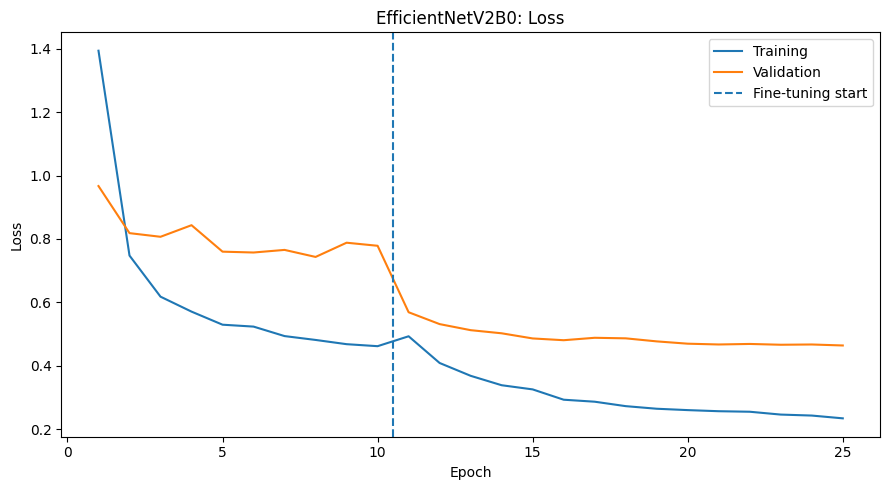

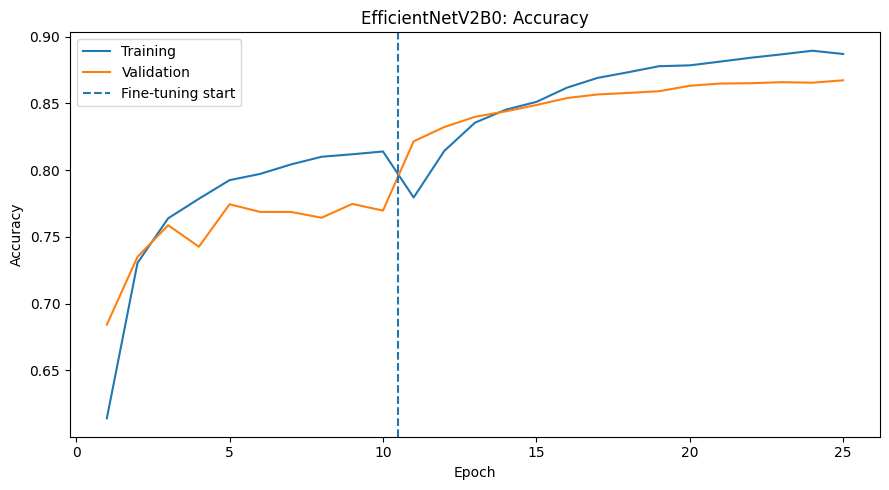

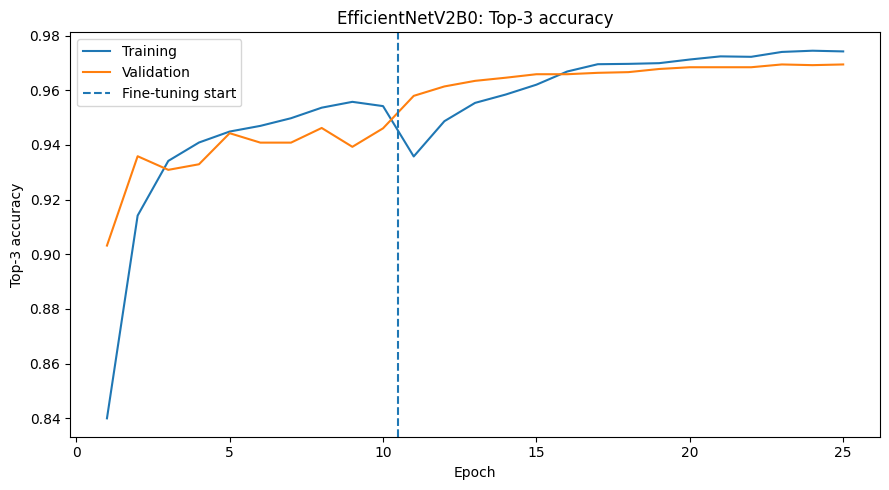

In [22]:
save_training_plot(
    "loss",
    "val_loss",
    "Loss",
    "efficientnetv2_loss",
)


save_training_plot(
    "sparse_accuracy",
    "val_sparse_accuracy",
    "Accuracy",
    "efficientnetv2_accuracy",
)


save_training_plot(
    "top3_accuracy",
    "val_top3_accuracy",
    "Top-3 accuracy",
    "efficientnetv2_top3_accuracy",
)

In [23]:
best_model = (
    tf.keras.models.load_model(
        best_model_path
    )
)


test_evaluation = (
    best_model.evaluate(
        test_ds,

        return_dict=True,

        verbose=1,
    )
)


print(
    "Keras test evaluation:"
)


for metric_name, metric_value in (
    test_evaluation.items()
):
    print(
        f"{metric_name}: "
        f"{metric_value:.6f}"
    )

395/395 ━━━━━━━━━━━━━━━━━━━━ 33s 67ms/step - loss: 0.5313 - sparse_accuracy: 0.8473 - top3_accuracy: 0.9611
Keras test evaluation:
loss: 0.531269
sparse_accuracy: 0.847348
top3_accuracy: 0.961124


In [24]:
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

In [25]:
prediction_start = (
    time.perf_counter()
)


probabilities = best_model.predict(
    test_ds,
    verbose=1,
)


prediction_seconds = (
    time.perf_counter()
    - prediction_start
)

395/395 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step


In [26]:
true_labels = np.concatenate(
    [
        batch_labels.numpy()

        for _, batch_labels
        in test_ds
    ]
)

In [27]:
predicted_labels = np.argmax(
    probabilities,
    axis=1,
)


confidence = np.max(
    probabilities,
    axis=1,
)


top3_classes = np.argsort(
    probabilities,
    axis=1,
)[:, -3:][:, ::-1]


top3_correct = np.any(
    top3_classes
    == true_labels[:, None],

    axis=1,
)

In [28]:
metrics = {
    "test_images": int(
        len(true_labels)
    ),

    "accuracy": float(
        accuracy_score(
            true_labels,
            predicted_labels,
        )
    ),

    "macro_precision": float(
        precision_score(
            true_labels,
            predicted_labels,

            average="macro",

            zero_division=0,
        )
    ),

    "macro_recall": float(
        recall_score(
            true_labels,
            predicted_labels,

            average="macro",

            zero_division=0,
        )
    ),

    "macro_f1": float(
        f1_score(
            true_labels,
            predicted_labels,

            average="macro",

            zero_division=0,
        )
    ),

    "weighted_f1": float(
        f1_score(
            true_labels,
            predicted_labels,

            average="weighted",

            zero_division=0,
        )
    ),

    "top3_accuracy": float(
        top3_correct.mean()
    ),

    "prediction_seconds": float(
        prediction_seconds
    ),

    "milliseconds_per_image": float(
        prediction_seconds
        / len(true_labels)
        * 1000
    ),

    "images_per_second": float(
        len(true_labels)
        / prediction_seconds
    ),

    "parameter_count": int(
        best_model.count_params()
    ),

    "model_file_size_mb": float(
        best_model_path.stat().st_size
        / 1024
        / 1024
    ),
}

In [29]:
(
    REPORT_DIR
    / "test_metrics.json"
).write_text(
    json.dumps(
        metrics,
        indent=2,
    ),

    encoding="utf-8",
)


print(
    json.dumps(
        metrics,
        indent=2,
    )
)

{
  "test_images": 12630,
  "accuracy": 0.847347585114806,
  "macro_precision": 0.7798589686173238,
  "macro_recall": 0.7691839176252726,
  "macro_f1": 0.7687978581886817,
  "weighted_f1": 0.8472125559425373,
  "top3_accuracy": 0.9611243072050673,
  "prediction_seconds": 24.242322322999826,
  "milliseconds_per_image": 1.9194237785431374,
  "images_per_second": 520.9896903324864,
  "parameter_count": 6263419,
  "model_file_size_mb": 40.469356536865234
}


In [30]:
class_report = (
    classification_report(
        true_labels,
        predicted_labels,

        labels=list(
            range(43)
        ),

        output_dict=True,

        zero_division=0,
    )
)


class_report_frame = (
    pd.DataFrame(
        class_report
    ).transpose()
)


class_report_frame.to_csv(
    REPORT_DIR
    / "classification_report.csv"
)


display(
    class_report_frame.head()
)

,precision,recall,f1-score,support
0,0.882353,0.500000,0.638298,60.0
1,0.854575,0.726389,0.785285,720.0
2,0.677457,0.781333,0.725697,750.0
3,0.728682,0.626667,0.673835,450.0
4,0.802778,0.875758,0.837681,660.0


In [31]:
confusion = confusion_matrix(
    true_labels,
    predicted_labels,

    labels=list(
        range(43)
    ),
)


confusion_frame = pd.DataFrame(
    confusion,

    index=[
        f"true_{class_id}"
        for class_id
        in range(43)
    ],

    columns=[
        f"pred_{class_id}"
        for class_id
        in range(43)
    ],
)


confusion_frame.to_csv(
    REPORT_DIR
    / "confusion_matrix.csv"
)

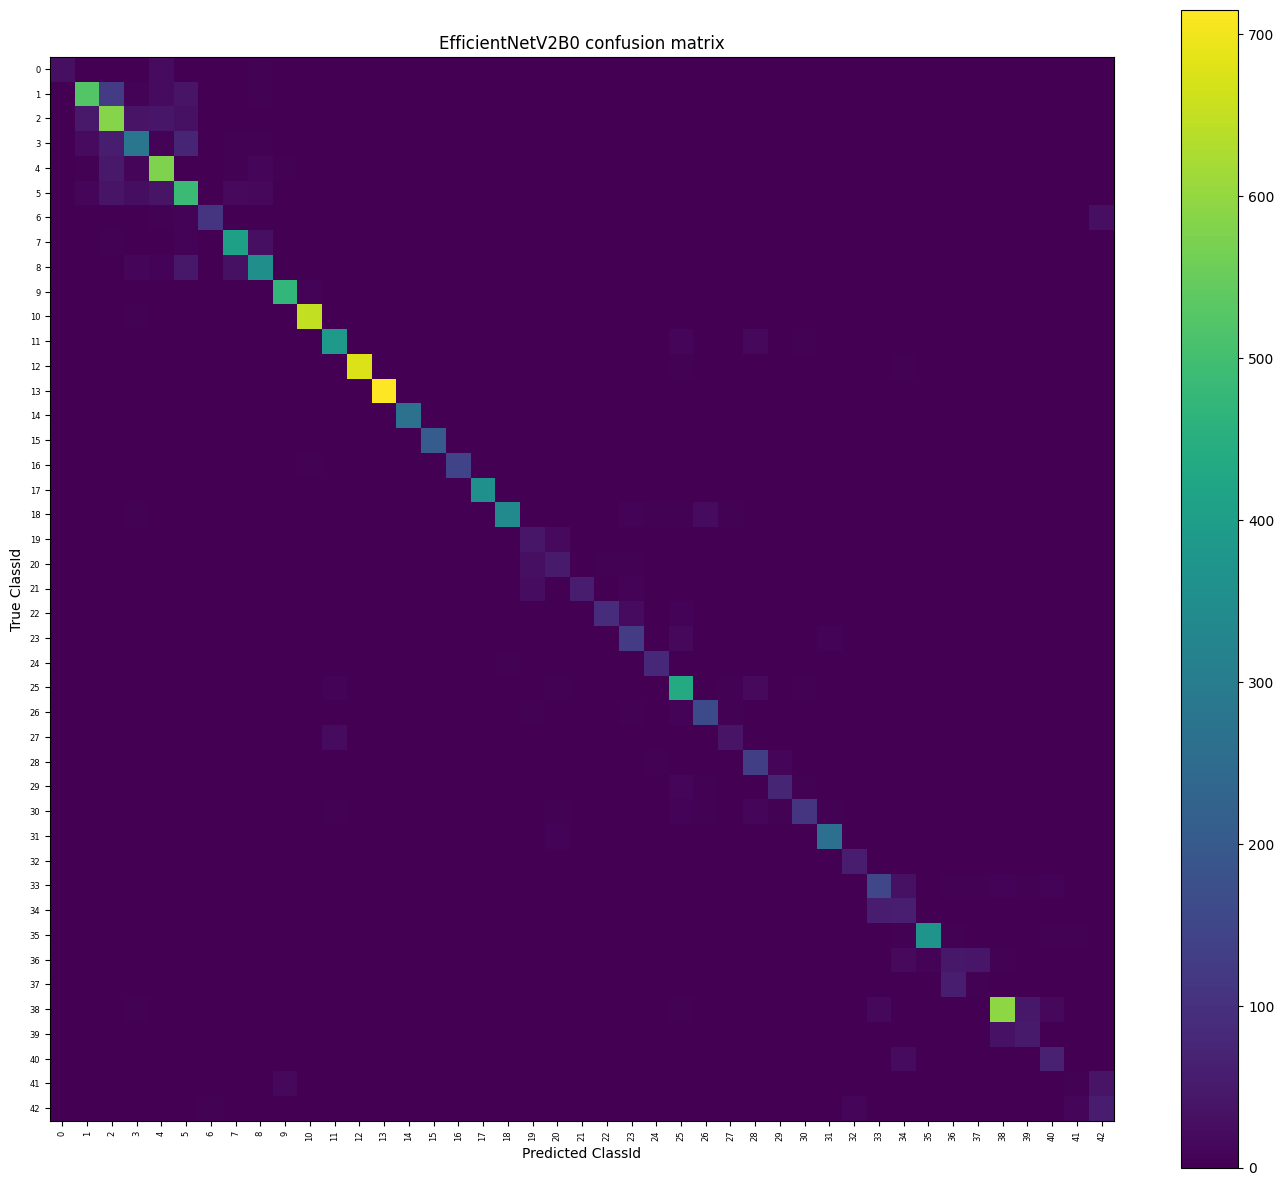

In [32]:
plt.figure(
    figsize=(14, 12)
)


plt.imshow(
    confusion
)


plt.colorbar()


plt.xlabel(
    "Predicted ClassId"
)

plt.ylabel(
    "True ClassId"
)

plt.title(
    "EfficientNetV2B0 confusion matrix"
)


plt.xticks(
    range(43),

    rotation=90,

    fontsize=6,
)


plt.yticks(
    range(43),

    fontsize=6,
)


plt.tight_layout()


plt.savefig(
    FIGURE_DIR
    / "efficientnetv2_confusion_matrix.pdf",

    bbox_inches="tight",
)


plt.savefig(
    FIGURE_DIR
    / "efficientnetv2_confusion_matrix.png",

    dpi=180,

    bbox_inches="tight",
)


plt.show()

In [33]:
test_predictions = data[
    "test_frame"
][
    [
        "Path",
        "ClassId",
    ]
].copy()


test_predictions = (
    test_predictions.rename(
        columns={
            "ClassId":
            "true_class_id"
        }
    )
)


test_predictions[
    "predicted_class_id"
] = predicted_labels


test_predictions[
    "confidence"
] = confidence


test_predictions[
    "correct"
] = (
    test_predictions[
        "true_class_id"
    ]
    ==
    test_predictions[
        "predicted_class_id"
    ]
)


for rank in range(3):
    test_predictions[
        f"top{rank + 1}_class_id"
    ] = top3_classes[:, rank]


    test_predictions[
        f"top{rank + 1}_probability"
    ] = probabilities[
        np.arange(
            len(probabilities)
        ),

        top3_classes[:, rank],
    ]


test_predictions.to_csv(
    REPORT_DIR
    / "test_predictions.csv",

    index=False,
)


display(
    test_predictions.head()
)

,Path,true_class_id,predicted_class_id,confidence,correct,top1_class_id,top1_probability,top2_class_id,top2_probability,top3_class_id,top3_probability
0,Test/00000.png,16,16,0.999992,True,16,0.999992,10,8.025689e-06,9,2.652151e-07
1,Test/00001.png,1,1,0.972547,True,1,0.972547,2,2.702299e-02,5,2.666415e-04
2,Test/00002.png,38,38,0.972337,True,38,0.972337,39,2.765922e-02,33,2.597532e-06
3,Test/00003.png,33,34,0.399007,False,34,0.399007,33,2.725996e-01,38,2.643266e-01
4,Test/00004.png,11,11,1.000000,True,11,1.000000,25,2.837075e-09,28,3.878418e-10


In [34]:
required_outputs = [
    MODEL_DIR
    / "best_efficientnetv2b0.keras",

    MODEL_DIR
    / "final_efficientnetv2b0.keras",

    REPORT_DIR
    / "model_summary.txt",

    REPORT_DIR
    / "training_history.csv",

    REPORT_DIR
    / "training_summary.json",

    REPORT_DIR
    / "test_metrics.json",

    REPORT_DIR
    / "classification_report.csv",

    REPORT_DIR
    / "confusion_matrix.csv",

    REPORT_DIR
    / "test_predictions.csv",

    FIGURE_DIR
    / "efficientnetv2_loss.pdf",

    FIGURE_DIR
    / "efficientnetv2_accuracy.pdf",

    FIGURE_DIR
    / "efficientnetv2_confusion_matrix.pdf",
]


missing_outputs = []


for path in required_outputs:
    if path.exists():
        print("OK:", path)
    else:
        print("MISSING:", path)
        missing_outputs.append(path)


if missing_outputs:
    raise FileNotFoundError(
        f"Не созданы итоговые файлы:\n"
        f"{missing_outputs}"
    )


print(
    "\nEFFICIENTNETV2 STAGE COMPLETED."
)

OK: /kaggle/working/efficientnetv2_outputs/models/best_efficientnetv2b0.keras
OK: /kaggle/working/efficientnetv2_outputs/models/final_efficientnetv2b0.keras
OK: /kaggle/working/efficientnetv2_outputs/reports/model_summary.txt
OK: /kaggle/working/efficientnetv2_outputs/reports/training_history.csv
OK: /kaggle/working/efficientnetv2_outputs/reports/training_summary.json
OK: /kaggle/working/efficientnetv2_outputs/reports/test_metrics.json
OK: /kaggle/working/efficientnetv2_outputs/reports/classification_report.csv
OK: /kaggle/working/efficientnetv2_outputs/reports/confusion_matrix.csv
OK: /kaggle/working/efficientnetv2_outputs/reports/test_predictions.csv
OK: /kaggle/working/efficientnetv2_outputs/figures/efficientnetv2_loss.pdf
OK: /kaggle/working/efficientnetv2_outputs/figures/efficientnetv2_accuracy.pdf
OK: /kaggle/working/efficientnetv2_outputs/figures/efficientnetv2_confusion_matrix.pdf

EFFICIENTNETV2 STAGE COMPLETED.


In [35]:
import shutil


archive_path = shutil.make_archive(
    base_name=(
        "/kaggle/working/"
        "efficientnetv2_results"
    ),

    format="zip",

    root_dir=OUTPUT_ROOT,
)


print(
    "Archive created:"
)

print(
    archive_path
)

Archive created:
/kaggle/working/efficientnetv2_results.zip
